# 00 - Preparação

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração de estilo global do Seaborn
sns.set_theme(style="whitegrid", palette="muted")

# Geração de dados sintéticos
np.random.seed(101)
n = 300

dados = {
    'idade': np.random.normal(35, 10, n).astype(int),
    'plano': np.random.choice(['Gratuito', 'Básico', 'Pro'], n, p=[0.5, 0.3, 0.2]),
    'tempo_uso_horas': np.random.uniform(1, 50, n),
    'bugs_reportados': np.random.poisson(2, n),
    'satisfacao': np.random.randint(1, 11, n)
}

df_sistema = pd.DataFrame(dados)

# Ajustando regras de negócio sintéticas para gerar correlações visuais
df_sistema.loc[df_sistema['plano'] == 'Pro', 'tempo_uso_horas'] += 15
df_sistema.loc[df_sistema['plano'] == 'Pro', 'satisfacao'] += 2
df_sistema['satisfacao'] = df_sistema['satisfacao'] - (df_sistema['bugs_reportados'] * 0.5)
df_sistema['satisfacao'] = df_sistema['satisfacao'].clip(1, 10).astype(int)
df_sistema['idade'] = df_sistema['idade'].clip(18, 70)


# Parte 1 - Distribuições e Contagens

**Contagem por tipo de plano**

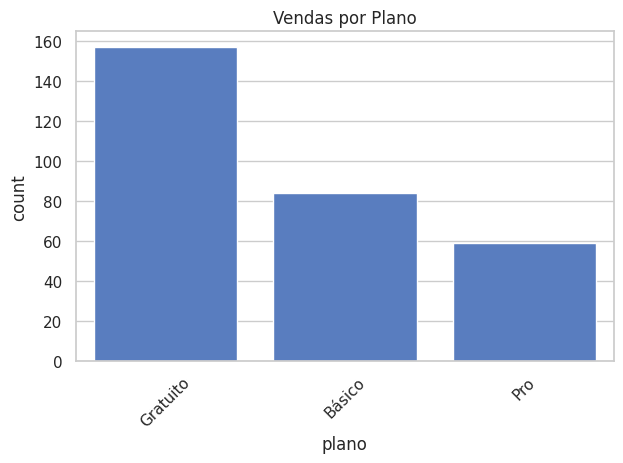

In [4]:
sns.countplot(data=df_sistema, x='plano')
plt.title('Vendas por Plano')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Análise de distribuição por idade**

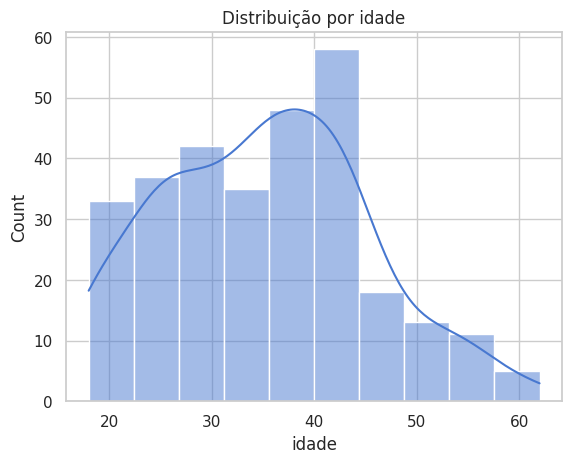

In [5]:
sns.histplot(data=df_sistema, x='idade', kde=True)
plt.title('Distribuição por idade')
plt.show()

**Parte 2 - Relações Categóricas e Numéricas**

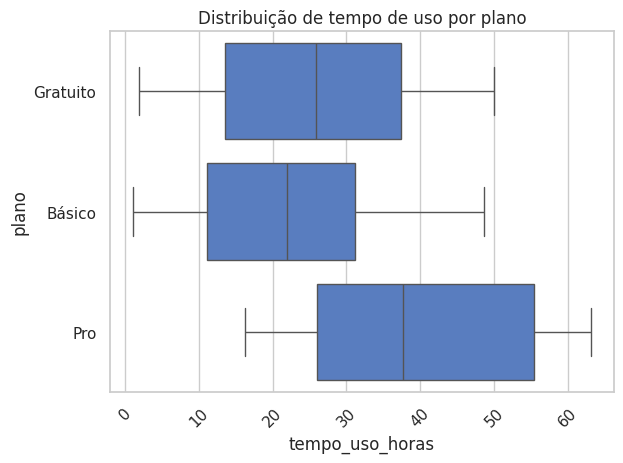

In [9]:
sns.boxplot(data=df_sistema, x='tempo_uso_horas', y='plano')
plt.title('Distribuição de tempo de uso por plano')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

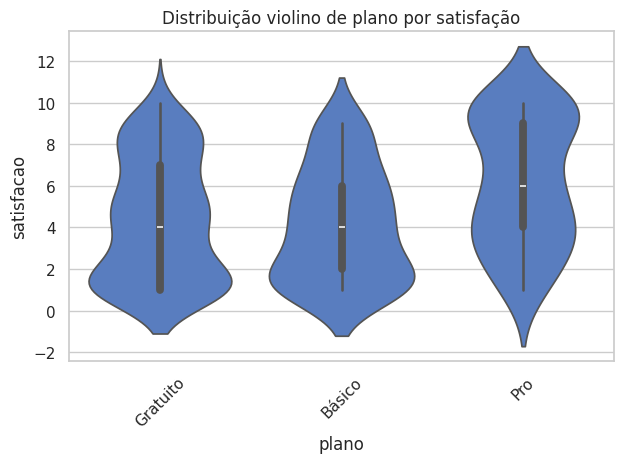

In [10]:
sns.violinplot(data=df_sistema, x='plano', y='satisfacao')
plt.title('Distribuição violino de plano por satisfação')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Parte 3 - Correlações e Análise Multivariada

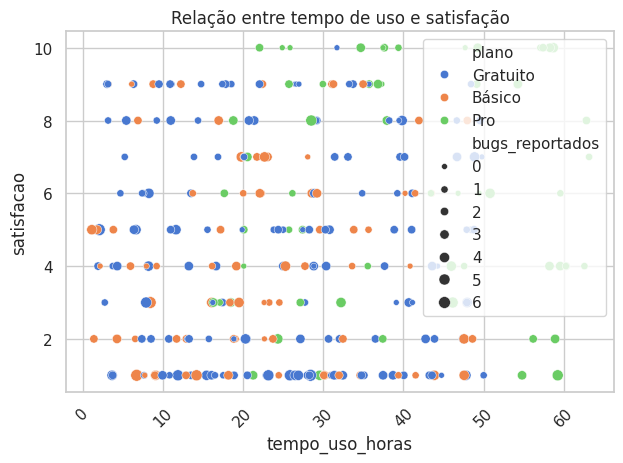

In [12]:
sns.scatterplot(data=df_sistema, x='tempo_uso_horas', y='satisfacao', hue='plano', size='bugs_reportados')
plt.title('Relação entre tempo de uso e satisfação')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

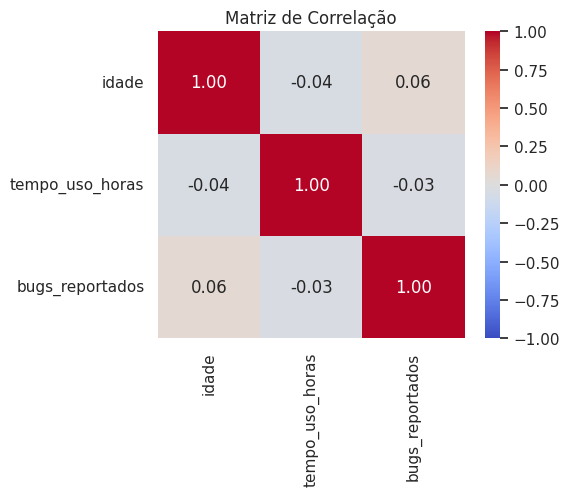

In [17]:
corr = df_sistema[['idade', 'tempo_uso_horas', 'bugs_reportados']].corr()
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, square=True)
plt.title('Matriz de Correlação')
plt.tight_layout()
plt.show()

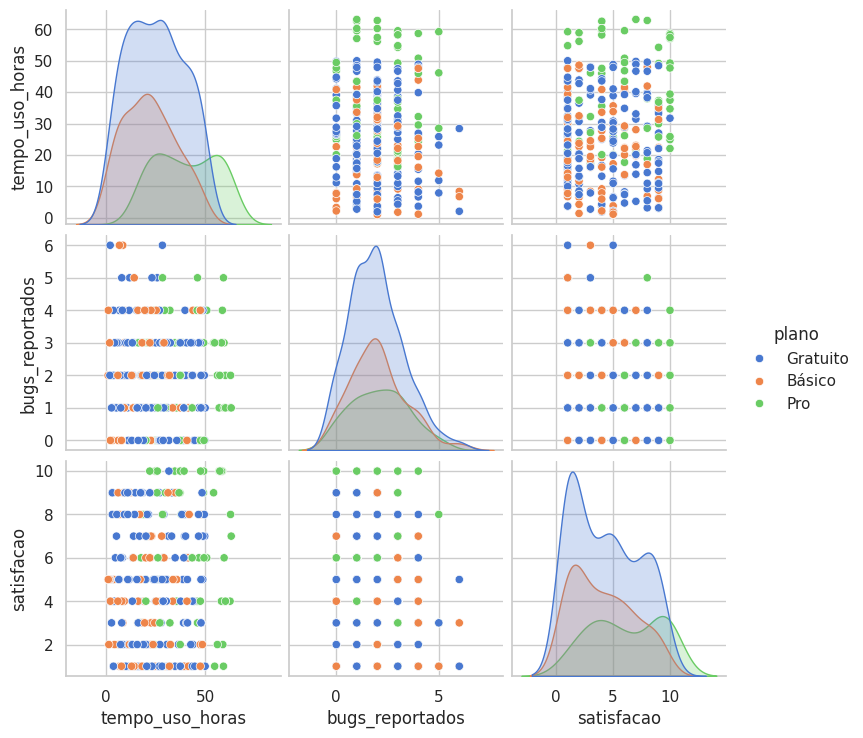

In [19]:
sns.pairplot(data=df_sistema, vars=['tempo_uso_horas', 'bugs_reportados', 'satisfacao'], hue='plano', diag_kind='kde', height=2.5)
plt.show()